# 01 — Simulator validation

**What this notebook is for.** `PROJECT_SPEC.md` §12 makes Weeks 1–2 ship a
differentiable transfer-matrix simulator together with *three validations and a
gradient check*. The validations live in `tests/test_tmm.py` and run in CI on
every commit; this notebook is the narrative version — the same claims, shown
rather than asserted.

Nothing here computes physics. Every number comes from `src/`, per §15:
*logic lives in `src/`, narrative in `notebooks/`.*

**The four claims:**

| | Claim | Why it is the right test |
|---|---|---|
| 1 | With no film, the stack reduces to the analytic Fresnel result | Ties the stack machinery back to §4.2 |
| 2 | A quarter-wave coating nulls reflection at its design wavelength | A *prediction*, written nowhere in the code |
| 3 | The model agrees with the reference `tmm` package | The only check against someone else's implementation |
| 4 | Autograd derivatives match finite differences | §5.3 builds every error bar from these |


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tmm  # validation only — never imported from src/ (§0.1)
import torch

from src import tmm_torch as pt

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.facecolor": "white"})
WAVELENGTHS = torch.linspace(400.0, 800.0, 401, dtype=torch.float64)

---
## Validation 1 — the no-film limit

Remove the film and the stack must reproduce the closed-form Fresnel
coefficients of §4.2 exactly, at every angle.

This is the weakest of the three tests on its own, because it only exercises a
single interface matrix. Its value is that it anchors everything else: if this
disagreed, nothing further would be worth looking at.

worst deviation from the closed form: 8.88e-16


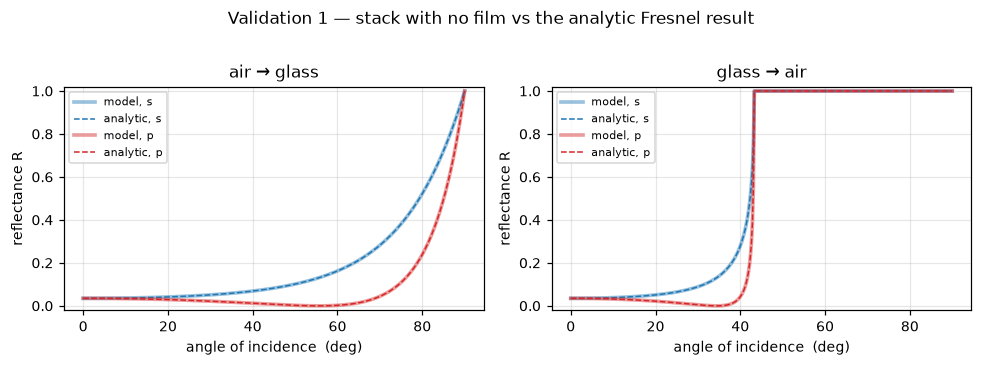

In [2]:
angles = np.linspace(0.0, np.pi / 2 - 1e-6, 400)


def analytic_R(n_i, n_j, theta, pol):
    """§4.2 in closed form — deliberately not calling src, so this is a check."""
    import cmath
    sin_t = (n_i / n_j) * cmath.sin(theta)
    cos_t = cmath.sqrt(1 - sin_t**2)
    if (n_j * cos_t).imag < 0:
        cos_t = -cos_t
    cos_i = cmath.cos(theta)
    if pol == "s":
        r = (n_i * cos_i - n_j * cos_t) / (n_i * cos_i + n_j * cos_t)
    else:
        r = (n_j * cos_i - n_i * cos_t) / (n_j * cos_i + n_i * cos_t)
    return abs(r) ** 2


fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, (n_i, n_j, label) in zip(
    axes, [(1.0, 1.46, "air → glass"), (1.46, 1.0, "glass → air")], strict=True
):
    for pol, colour in (("s", "#1f77b4"), ("p", "#d62728")):
        model = pt.stack_reflectance(550.0, [], [n_i, n_j], torch.tensor(angles), pol)
        exact = [analytic_R(n_i, n_j, float(a), pol) for a in angles]
        ax.plot(np.degrees(angles), model.numpy(), color=colour, lw=2.4, alpha=0.45,
                label=f"model, {pol}")
        ax.plot(np.degrees(angles), exact, color=colour, lw=1.0, ls="--",
                label=f"analytic, {pol}")
    ax.set(title=label, xlabel="angle of incidence  (deg)", ylabel="reflectance R",
           ylim=(-0.02, 1.02))
    ax.legend(fontsize=7, loc="upper left")

fig.suptitle("Validation 1 — stack with no film vs the analytic Fresnel result", y=1.02)
fig.tight_layout()

worst = max(
    abs(pt.stack_reflectance(550.0, [], [n_i, n_j], torch.tensor(angles), pol).numpy()
        - np.array([analytic_R(n_i, n_j, float(a), pol) for a in angles])).max()
    for n_i, n_j in [(1.0, 1.46), (1.46, 1.0)] for pol in ("s", "p")
)
print(f"worst deviation from the closed form: {worst:.2e}")

The dashed analytic curve is hidden under the model curve everywhere.

Two features worth naming, because both are asserted as tests:

- **Brewster's angle** — the red `p` curve touches exactly zero (56.3° left, 34.4°
  right). This is why polarised sunglasses cut glare.
- **The critical angle** — on the right, going from dense to thin, both curves hit
  1 at 43.2° and stay there. Total internal reflection; the mechanism behind
  optical fibre.

---
## Validation 2 — the quarter-wave null

The sharpest of the three. A single layer of index $\sqrt{n_\text{sub}}$ and
optical thickness $\lambda/4$ cancels its own reflection **exactly** at the
design wavelength.

Nothing in `src/` mentions anti-reflection coatings. This result has to emerge
from the interface and layer matrices each being right and correctly ordered —
so unlike Validation 1, it is a genuine prediction rather than a transcription
being checked.

glass       uncoated R = 0.0426   coated R = 1.75e-34
mid-index   uncoated R = 0.1552   coated R = 1.47e-32
silicon     uncoated R = 0.3483   coated R = 1.38e-32


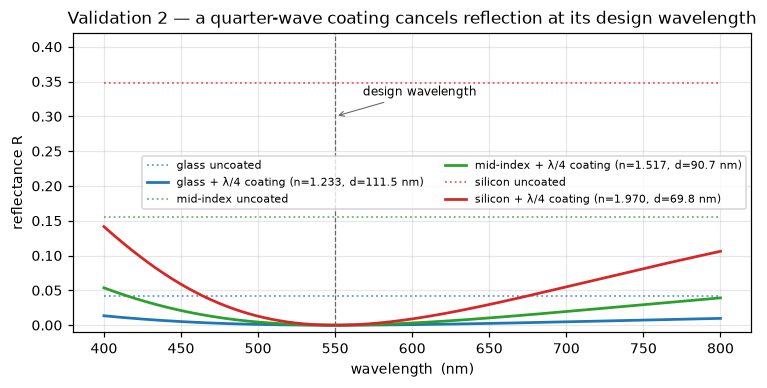

In [3]:
design = 550.0
substrates = [(1.52, "glass"), (2.30, "mid-index"), (3.88, "silicon")]

fig, ax = plt.subplots(figsize=(7, 3.6))
for (n_sub, name), colour in zip(substrates, ["#1f77b4", "#2ca02c", "#d62728"], strict=True):
    n_film = float(np.sqrt(n_sub))
    d = design / (4.0 * n_film)
    coated = pt.stack_reflectance(WAVELENGTHS, [d], [1.0, n_film, n_sub], 0.0, "s")
    bare = pt.stack_reflectance(WAVELENGTHS, [], [1.0, n_sub], 0.0, "s")
    ax.plot(WAVELENGTHS, bare, color=colour, ls=":", lw=1.2, alpha=0.7,
            label=f"{name} uncoated")
    ax.plot(WAVELENGTHS, coated, color=colour, lw=1.8,
            label=f"{name} + λ/4 coating (n={n_film:.3f}, d={d:.1f} nm)")

ax.axvline(design, color="0.4", lw=0.8, ls="--")
ax.annotate("design wavelength", (design, 0.30), (design + 18, 0.33), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.7, color="0.4"))
ax.set(xlabel="wavelength  (nm)", ylabel="reflectance R", ylim=(-0.01, 0.42),
       title="Validation 2 — a quarter-wave coating cancels reflection at its design wavelength")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()

for n_sub, name in substrates:
    n_film = float(np.sqrt(n_sub))
    d = design / (4.0 * n_film)
    R = pt.stack_reflectance(torch.tensor(design, dtype=torch.float64), [d],
                             [1.0, n_film, n_sub], 0.0, "s").item()
    bare = pt.stack_reflectance(torch.tensor(design, dtype=torch.float64), [],
                                [1.0, n_sub], 0.0, "s").item()
    print(f"{name:10s}  uncoated R = {bare:.4f}   coated R = {R:.2e}")

Silicon reflects **35%** of light bare, and **1.4e-32** — machine zero — with
69.8 nm of coating on it.

The tests around this one are mostly guards against it passing for the wrong
reason: the uncoated substrate must reflect something first, the minimum must be
*located* at the design wavelength rather than merely be small there, and an
index off by ±25% must spoil the null.

### The absentee layer

A second prediction from the same physics. A layer of **half**-wave optical
thickness accumulates $\delta = \pi$, which makes its matrix $-I$ — so it drops
out of the product entirely and the stack reflects exactly as bare substrate,
*whatever the layer is made of*.

This is a direct test of the phase convention: a stray factor of two anywhere in
$\delta = (2\pi/\lambda)\,\tilde n\,d\cos\theta$ would move it.

period from the plot : 139.59 nm
λ / 2n               : 139.59 nm


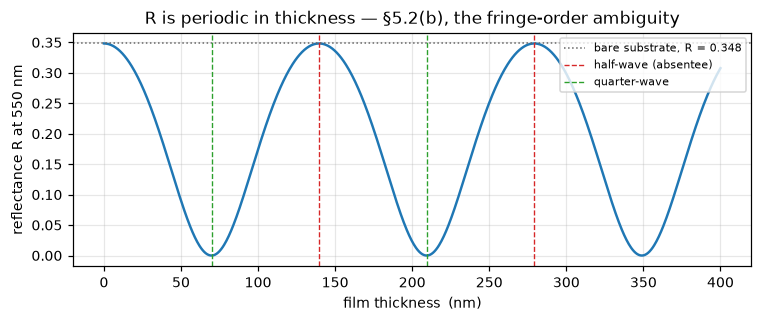

In [4]:
thicknesses = torch.linspace(0.0, 400.0, 801, dtype=torch.float64)
n_film, n_sub = 1.97, 3.88
R = torch.stack([
    pt.stack_reflectance(torch.tensor(design, dtype=torch.float64), [float(d)],
                         [1.0, n_film, n_sub], 0.0, "s")
    for d in thicknesses
])
bare = pt.stack_reflectance(torch.tensor(design, dtype=torch.float64), [],
                            [1.0, n_sub], 0.0, "s").item()

fig, ax = plt.subplots(figsize=(7, 3.0))
ax.plot(thicknesses, R, color="#1f77b4", lw=1.6)
ax.axhline(bare, color="0.4", ls=":", lw=1.0, label=f"bare substrate, R = {bare:.3f}")
half_wave = design / (2 * n_film)
for k in (1, 2):
    ax.axvline(k * half_wave, color="#d62728", ls="--", lw=0.9,
               label="half-wave (absentee)" if k == 1 else None)
    ax.axvline((k - 0.5) * half_wave, color="#2ca02c", ls="--", lw=0.9,
               label="quarter-wave" if k == 1 else None)
ax.set(xlabel="film thickness  (nm)", ylabel="reflectance R at 550 nm",
       title="R is periodic in thickness — §5.2(b), the fringe-order ambiguity")
ax.legend(fontsize=7)
fig.tight_layout()

print(f"period from the plot : {half_wave:.2f} nm")
print(f"λ / 2n               : {design / (2 * n_film):.2f} nm")

**This plot is the project's central difficulty, drawn.**

R returns to exactly the same value every $\lambda/2n$ of thickness. Two films
differing by one period produce *identical* spectra at this wavelength — so the
measurement genuinely cannot distinguish them, and any estimator claiming to
have done so is claiming information the physics does not contain.

§5.2(b) calls this the fringe-order ambiguity, and §8.3 is about the consequence:
the posterior is **multimodal**, which a single mean-and-variance output cannot
represent. It will average two correct answers into one wrong one.

---
## Validation 3 — agreement with the reference package

The only check against an implementation written by somebody else. Validations 1
and 2 compare the model against physics this project also transcribed; a shared
misreading would survive both.

§0.1's standing decision is *write the forward model; import `tmm` only to
validate* — so `tmm` is a dev-only dependency and `tests/test_smoke.py` asserts
no module under `src/` imports it.

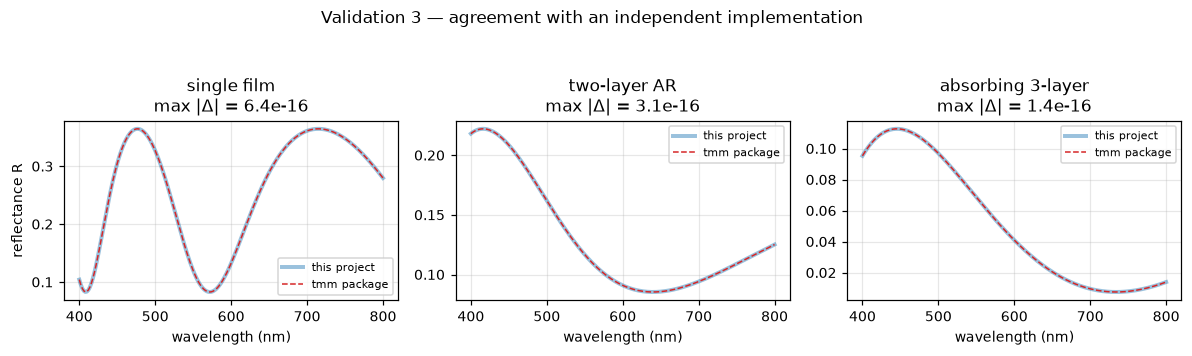

In [5]:
stacks = [
    ("single film", [500.0], [1.0, 1.46, 3.88]),
    ("two-layer AR", [120.0, 65.0], [1.0, 1.38, 2.30, 1.52]),
    ("absorbing 3-layer", [80.0, 40.0, 200.0], [1.0, 1.5 + 0.05j, 2.3, 4.0 + 1.5j, 3.88]),
]
lam = np.linspace(400.0, 800.0, 201)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.0), sharex=True)
for ax, (name, d, n) in zip(axes, stacks, strict=True):
    mine = pt.stack_reflectance(torch.tensor(lam), d, n, 0.3, "s").numpy()
    ref = np.array([abs(tmm.coh_tmm("s", list(n), [np.inf, *d, np.inf], 0.3, w)["r"]) ** 2
                    for w in lam])
    ax.plot(lam, mine, color="#1f77b4", lw=2.6, alpha=0.45, label="this project")
    ax.plot(lam, ref, color="#d62728", lw=1.0, ls="--", label="tmm package")
    ax.set(title=f"{name}\nmax |Δ| = {np.abs(mine - ref).max():.1e}",
           xlabel="wavelength (nm)")
    ax.legend(fontsize=7)
axes[0].set_ylabel("reflectance R")
fig.suptitle("Validation 3 — agreement with an independent implementation", y=1.06)
fig.tight_layout()

Agreement is at the level of float64 round-off accumulating through a chain of
matrix products — about `1e-15`, across 1,968 comparisons in the test suite
spanning six stacks, four angles and both polarisations.

The tests compare the **complex amplitude**, not only the reflectance. $|r|^2$
discards the phase, and §7.3's reconstruction loss, §5.3's Jacobian and any
ellipsometry under §3 all depend on the amplitude. The signs agree too — which
independently confirms the $r_p$ convention chosen back in DTFM-006.

---
## The gradient check

The reason the simulator is written in torch at all. §5.3 takes the Jacobian
$J[i,k] = \partial f(\lambda_i)/\partial\theta_k$ from autograd rather than
finite differences, and Fisher information, the Cramér–Rao bound and the
thickness–index correlation are all computed from it.

A wrong derivative would not raise. It would produce a confident, wrong error
bar — and §15 calls reporting a fit without an honest error bar a disqualifying
instinct in this field.

autograd  ∂R/∂d = 0.001628850697780  per nm
  h = 4.0e-02   error = 7.777e-10
  h = 2.0e-02   error = 1.944e-10
  h = 1.0e-02   error = 4.861e-11
  h = 5.0e-03   error = 1.214e-11


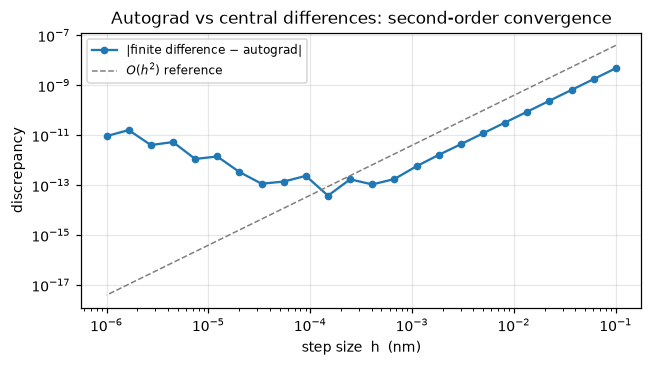

In [6]:
def R_of_d(d, wavelength=633.0):
    return pt.stack_reflectance(torch.tensor(wavelength, dtype=torch.float64), [d],
                                [1.0, 1.46, 3.88], 0.2, "s")


d0 = torch.tensor(120.0, dtype=torch.float64, requires_grad=True)
R_of_d(d0).backward()
exact = d0.grad.item()

steps = np.logspace(-1, -6, 24)
errors = []
for h in steps:
    with torch.no_grad():
        fd = (R_of_d(torch.tensor(120.0 + h, dtype=torch.float64)).item()
              - R_of_d(torch.tensor(120.0 - h, dtype=torch.float64)).item()) / (2 * h)
    errors.append(abs(fd - exact))

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.loglog(steps, errors, "o-", color="#1f77b4", ms=4, label="|finite difference − autograd|")
ax.loglog(steps, 4e-6 * steps**2, "--", color="0.5", lw=1.0, label=r"$O(h^2)$ reference")
ax.set(xlabel="step size  h  (nm)", ylabel="discrepancy",
       title="Autograd vs central differences: second-order convergence")
ax.legend(fontsize=8)
fig.tight_layout()

print(f"autograd  ∂R/∂d = {exact:.15f}  per nm")
for h in (4e-2, 2e-2, 1e-2, 5e-3):
    with torch.no_grad():
        fd = (R_of_d(torch.tensor(120.0 + h, dtype=torch.float64)).item()
              - R_of_d(torch.tensor(120.0 - h, dtype=torch.float64)).item()) / (2 * h)
    print(f"  h = {h:7.1e}   error = {abs(fd - exact):.3e}")

The discrepancy falls as $h^2$ — the signature of a correct derivative — until
round-off takes over below $h \approx 10^{-3}$ and the curve turns up. Agreement
at a single step size could be coincidence; that slope could not.

### What this Jacobian already says about the project

§5.2(a) warns that thickness and refractive index are nearly degenerate: at a
single wavelength the measurement constrains only the product $n\cdot d$.
Dispersion breaks that partially. *How* partially is a number, and the Jacobian
gives it.

thickness–index correlation  ρ = -0.9468
§5.3: reporting this alongside a fitted value is what separates a
metrologist from someone who called curve_fit.


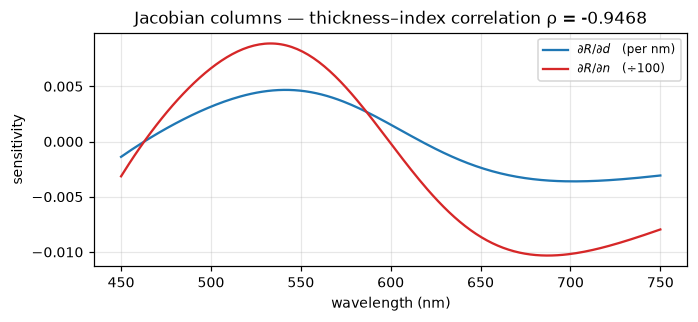

In [7]:
lam_fit = torch.linspace(450.0, 750.0, 200, dtype=torch.float64)
theta_true = torch.tensor([320.0, 1.46], dtype=torch.float64)


def spectrum(theta):
    return pt.stack_reflectance(lam_fit, [theta[0]], [1.0, theta[1], 3.88], 0.2, "s")


J = torch.autograd.functional.jacobian(spectrum, theta_true)
covariance = torch.linalg.inv(J.T @ J)
rho = (covariance[0, 1] / torch.sqrt(covariance[0, 0] * covariance[1, 1])).item()

fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.plot(lam_fit, J[:, 0], color="#1f77b4", label=r"$\partial R/\partial d$   (per nm)")
ax.plot(lam_fit, J[:, 1] / 100.0, color="#d62728",
        label=r"$\partial R/\partial n$   (÷100)")
ax.set(xlabel="wavelength (nm)", ylabel="sensitivity",
       title=f"Jacobian columns — thickness–index correlation ρ = {rho:+.4f}")
ax.legend(fontsize=8)
fig.tight_layout()

print(f"thickness–index correlation  ρ = {rho:+.4f}")
print("§5.3: reporting this alongside a fitted value is what separates a")
print("metrologist from someone who called curve_fit.")

The two columns are nearly proportional — that is what a correlation of
$\rho \approx -0.95$ looks like. Increasing the thickness and decreasing the
index change the spectrum in almost the same way, so the fit cannot cleanly
separate them.

This is not a defect in the model. It is a property of the *measurement*, and
quantifying it is the point: §5.3 notes that if an estimator sits near the
Cramér–Rao bound then the algorithm is fine and the measurement is the limit —
a conclusion worth stating out loud.

DTFM-034 turns this into the proper result, and §8.2 compares the network's
claimed uncertainty against it.

---
## Summary

| Claim | Result |
|---|---|
| No-film limit vs analytic Fresnel | agrees to ~1e-16 |
| Quarter-wave null | R = 1.4e-32 from 0.348 uncoated |
| Half-wave absentee layer | identical to bare substrate, any film index |
| Agreement with `tmm` | ~1e-15 over 1,968 comparisons |
| Autograd vs finite differences | $O(h^2)$, error ratio 4.00 per halving |

Everything above is asserted in `tests/` and runs in CI on every commit — this
notebook shows the same claims rather than establishing them.

**What is not yet true.** Every refractive index here is a number chosen by hand;
real optical constants arrive at DTFM-019. No spectrum here has noise, roughness
or instrument blur — those are §4.5, at DTFM-023–025. And nothing has been
*inverted*: recovering a thickness from a spectrum starts at DTFM-030.

Per §3a, all data in this project is synthetic and no lab access was available.